In [1]:
#Import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [30]:
df = pd.read_csv(r"C:\Users\anshu\Krish Naik Projects\Quick Commerce Project\quick_commerce_data_modified_cleaned.csv")

In [31]:
df.head

<bound method NDFrame.head of         Order_ID           Company      City  Customer_Age  Order_Value  \
0        1000001  Swiggy Instamart     Noida            46          702   
1        1000002  Flipkart Minutes  Amritsar            56         1007   
2        1000003  Flipkart Minutes    Mumbai            18         1212   
3        1000004  Swiggy Instamart     Delhi            23         1179   
4        1000005             Dunzo    Mumbai            44          586   
...          ...               ...       ...           ...          ...   
947747   1999996        Big Basket    Mumbai            48           72   
947748   1999997  Swiggy Instamart    Mumbai            33         1510   
947749   1999998          Jio Mart     Noida            29          637   
947750   1999999             Dunzo      Pune            42         1103   
947751   2000000        Amazon Now   Chennai            19          759   

        Delivery_Time_Min  Distance_Km  Items_Count     Product_Categ

#Q1) Which Quick Commerce Company has greatest revenue?#


<Axes: xlabel='Company'>

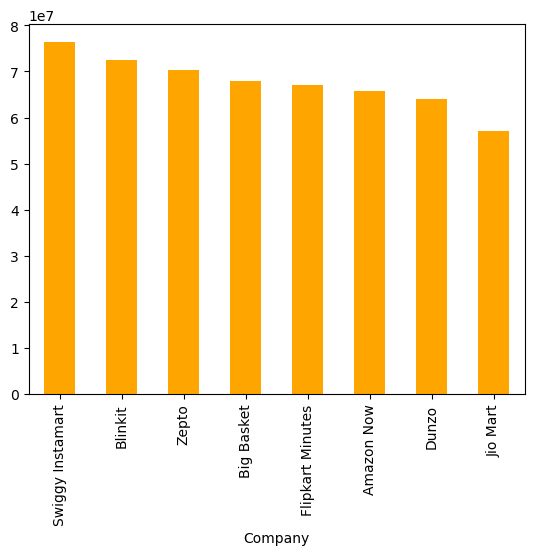

In [32]:
Company_revenue = df.groupby('Company')['Order_Value'].sum()

Company_revenue.sort_values(ascending=False).plot(kind='bar', color='orange')

In [33]:
#Swiggy Instamart has highest revenue 

#Q2) Which Quick Commerce Company has highest AOV?#


In [34]:
# Calculate Average Order Value (AOV) per company and sort the results
AOV = df.groupby('Company')['Order_Value'].mean().sort_values()

# Display the result
AOV

Company
Jio Mart            482.914592
Dunzo               540.317053
Amazon Now          557.510429
Flipkart Minutes    563.176472
Big Basket          575.065542
Zepto               593.258314
Blinkit             609.819198
Swiggy Instamart    644.927250
Name: Order_Value, dtype: float64

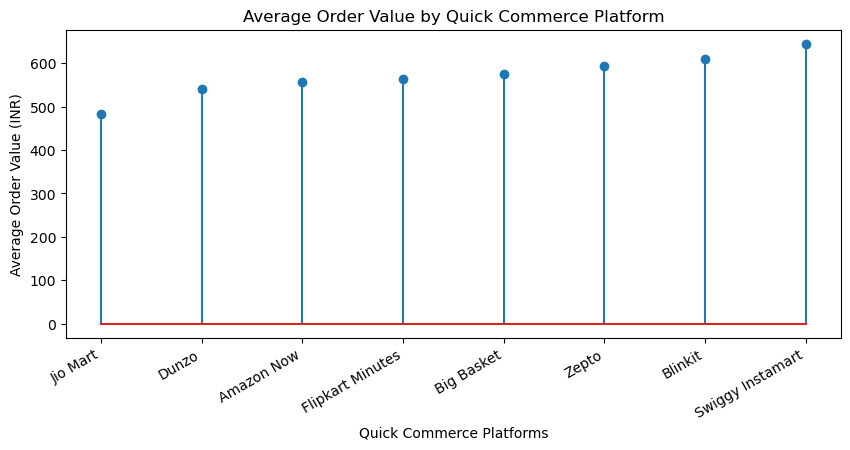

In [35]:
# Create a refined Stem Chart with proper labeling
plt.figure(figsize = (10,4))

plt.stem(AOV.index, AOV.values)     # Plotting the data

# Adding descriptive labels and title
plt.xlabel("Quick Commerce Platforms")
plt.ylabel("Average Order Value (INR)")
plt.title("Average Order Value by Quick Commerce Platform")

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, ha="right")

plt.show()

#Q3) How does Customer Rating Vary Across Platforms?#


In [36]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5


In [37]:
# Group Data - Calculate average rating for companies
df.groupby('Company')['Customer_Rating'].mean().sort_values()

Company
Dunzo               2.428024
Jio Mart            2.819747
Amazon Now          2.913417
Flipkart Minutes    3.016316
Big Basket          3.097902
Zepto               3.203062
Swiggy Instamart    3.279443
Blinkit             3.580762
Name: Customer_Rating, dtype: float64

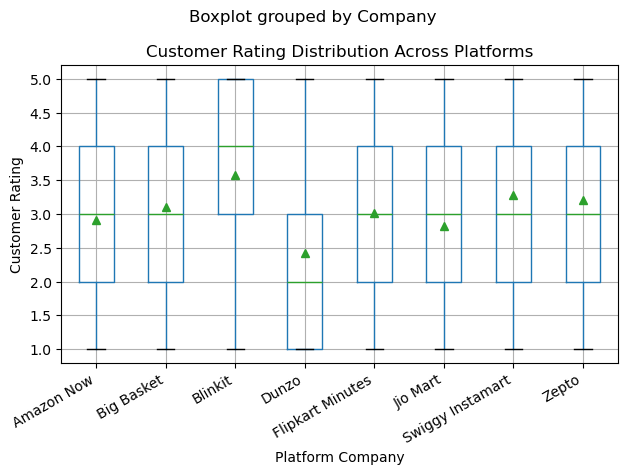

In [38]:
# Create a Box Plot to see rating distribution per company
df.boxplot(column = 'Customer_Rating', by = 'Company', showmeans = True)

# Add titles and labels
plt.title("Customer Rating Distribution Across Platforms")
plt.xlabel("Platform Company")
plt.ylabel("Customer Rating")

# Rotate x-axis labels for better fit
plt.xticks(rotation = 30, ha = 'right')

# Auto adjust spacing to prevent label overlapping
plt.tight_layout()
plt.show()

In [39]:
# Group Data to count the occurrences of each rating per company
grouped_rating = df.groupby(['Company', 'Customer_Rating']).size().unstack(fill_value=0)
grouped_rating

Customer_Rating,1,2,3,4,5
Company,,,,,
Amazon Now,15977,30351,30866,29697,11192
Big Basket,10143,30339,31020,30908,15637
Blinkit,1060,25553,25561,36708,30005
Dunzo,29818,36280,25377,25818,1170
Flipkart Minutes,12549,30786,31225,30985,13420
Jio Mart,18513,30515,31083,30089,8067
Swiggy Instamart,5000,30278,31039,30931,21227
Zepto,7618,29763,31367,30559,19258


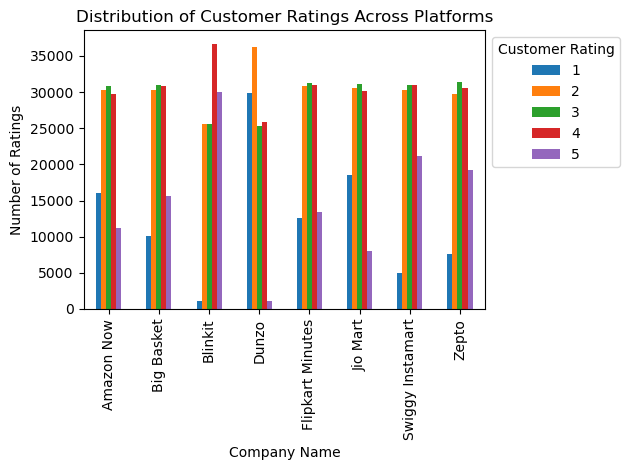

In [40]:
# Create a Bar Chart for the pivoted rating data
# Assumes 'grouped_rating' is the variable from the previous unstack() step
grouped_rating.plot(kind = 'bar')

# Adding labels and title for clarity
plt.xlabel("Company Name")
plt.ylabel("Number of Ratings")
plt.title("Distribution of Customer Ratings Across Platforms")

# Adjusting the legend position so it doesn't cover the bars
plt.legend(title = 'Customer Rating', bbox_to_anchor = (1, 1), loc = 'upper left')

# Auto-adjust spacing and show plot
plt.tight_layout()
plt.show()

#Q4) Does Delivery Time effect Delivery partner rating?#


In [41]:
df['Delivery_Time_Min'].mean()

np.float64(16.506619875241626)

In [42]:
df['Delivery_Partner_Rating'].mean()

np.float64(3.80029480285982)

In [43]:
# Calculate average rating for delivery timings
x= df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()
x

Delivery_Time_Min
5     3.803956
6     3.798555
7     3.805901
8     3.803807
9     3.804469
10    3.801688
11    3.799953
12    3.798843
13    3.795841
14    3.797351
15    3.797958
16    3.799191
17    3.802405
18    3.801744
19    3.809601
20    3.804773
21    3.803036
22    3.804585
23    3.794215
24    3.791258
25    3.800221
26    3.795316
27    3.799794
28    3.796314
29    3.792997
30    3.788537
31    3.807610
32    3.789012
33    3.781402
34    3.770451
35    3.779251
36    3.752239
37    3.732039
38    3.741307
39    3.799097
40    3.737589
Name: Delivery_Partner_Rating, dtype: float64

In [44]:
df['Delivery_Time_Min'].corr(df['Delivery_Partner_Rating'])

np.float64(-0.0027773408026700776)

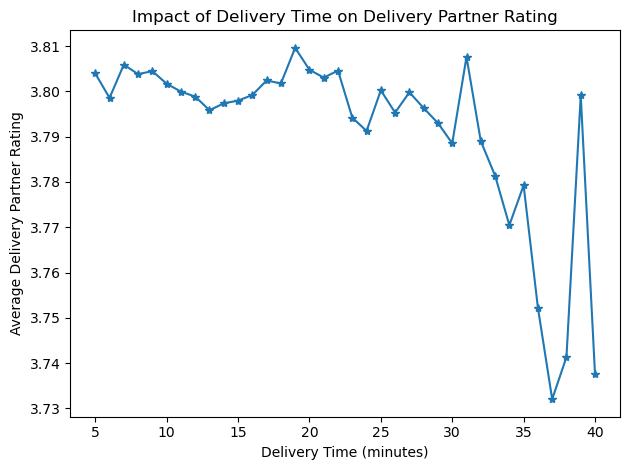

In [45]:
# Line Chart
# Assumes 'x' is the grouped data from the previous step: 
# x = df.groupby('Delivery_Time_Min')['Delivery_Partner_Rating'].mean()

x.plot(marker = '*')

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")

plt.tight_layout()
plt.show()

In [46]:
# syntax : pd.cut( col_name, bins, labels )

df['Delivery_Time_Bucket'] = pd.cut(
    df['Delivery_Time_Min'],
    bins = (0, 10, 20, 30, 40, 50),
    labels = ("Very Fast Delivery", "Fast Delivery", "Normal Delivery", 
              "Slow Delivery", "Very Slow Delivery")
)

In [47]:
# Calculate the average delivery partner rating for each time bucket
bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()

# Display the result
bucket_avg

C:\Users\anshu\AppData\Local\Temp\ipykernel_9884\734314334.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_avg = df.groupby('Delivery_Time_Bucket')['Delivery_Partner_Rating'].mean()


Delivery_Time_Bucket
Very Fast Delivery    3.803231
Fast Delivery         3.800835
Normal Delivery       3.798345
Slow Delivery         3.783646
Very Slow Delivery         NaN
Name: Delivery_Partner_Rating, dtype: float64

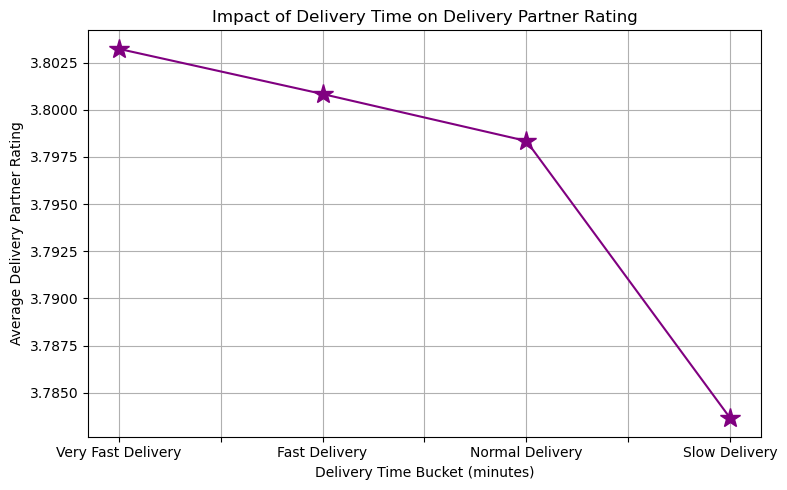

In [48]:
# Create a stylized line chart for bucketed delivery ratings
plt.figure(figsize=(8,5))

# Plotting with large star markers and a custom color
bucket_avg.plot(marker = '*', markersize = 15, color = 'purple')

# Labeling for context
plt.xlabel("Delivery Time Bucket (minutes)")
plt.ylabel("Average Delivery Partner Rating")
plt.title("Impact of Delivery Time on Delivery Partner Rating")

# Add a grid to make reading exact values easier
plt.grid(True)

plt.tight_layout()
plt.show()

#Q5) What is most popular product category in Swiggy Instamart for People of age group 30-40 in Mumbai#

In [49]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [51]:
# Filtering the dataframe based on multiple specific criteria
df_pc = df[
    (df['Company'] == 'Swiggy Instamart') & 
    ((df['Customer_Age'] >= 30) & (df['Customer_Age'] < 40)) & 
    (df['City'] == 'Mumbai')
]
df_pc.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
512,1000537,Swiggy Instamart,Mumbai,38,1157,14,5.7,18,Beverages,Cash on Delivery,4,1,4,Fast Delivery
872,1000910,Swiggy Instamart,Mumbai,32,926,20,14.2,3,Dairy,UPI,2,0,5,Fast Delivery
1148,1001204,Swiggy Instamart,Mumbai,37,234,19,7.6,6,Dairy,Debit Card,5,0,4,Fast Delivery
2783,1002919,Swiggy Instamart,Mumbai,31,423,15,4.0,10,Dairy,Cash on Delivery,2,0,3,Fast Delivery
4038,1004252,Swiggy Instamart,Mumbai,36,50,15,2.2,12,Dairy,Credit Card,3,0,3,Fast Delivery


In [52]:
# Most popular product category
df_pc['Product_Category'].value_counts()

Product_Category
Dairy                  368
Fruits & Vegetables    343
Groceries              341
Household              340
Snacks                 329
Personal Care          305
Beverages              299
Name: count, dtype: int64

In [ ]:
# Dairy is the most popular pc

#Q6) Which cities should these companies expand to based on the performance#

In [53]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [55]:
# Group Data by Company and City, then apply multiple aggregate functions
city_perf =  df.groupby(['Company', 'City']).agg(
    Total_Orders = ('Order_ID', 'count'),
    Avg_Rating = ("Customer_Rating", 'mean'),
    Avg_Delivery_Time = ('Delivery_Time_Min', 'mean'),
    Total_Revenue = ('Order_Value', 'sum')
).reset_index()
city_perf

,Company,City,Total_Orders,Avg_Rating,Avg_Delivery_Time,Total_Revenue
0,Amazon Now,Amritsar,9929,2.896666,18.167388,5469439
1,Amazon Now,Bengluru,9905,3.387683,19.183342,5629936
2,Amazon Now,Chennai,9847,2.904032,18.138722,5363559
3,Amazon Now,Delhi,9918,2.989716,8.294616,5891026
4,Amazon Now,Gurgaon,9797,2.921711,18.166173,6680388
...,...,...,...,...,...,...
91,Zepto,Jaipur,9678,3.112213,13.145278,4621428
92,Zepto,Kolkata,9825,3.173028,8.302901,5776955
93,Zepto,Mumbai,9861,3.412230,10.152013,6046485
94,Zepto,Noida,10070,3.206653,8.297617,7070769


In [56]:
# Filtering Best Cities based on given condition
best_cities = city_perf[
    (city_perf['Avg_Rating'] >= 3.5) & 
    (city_perf['Avg_Delivery_Time'] <= 15) & 
    (city_perf['Total_Orders'] > city_perf['Total_Orders'].median())
]

In [58]:
#best cities will be filtered based on the performance in the city
best_cities[['Company', 'City']]

,Company,City
24,Blinkit,Amritsar
26,Blinkit,Chennai
28,Blinkit,Gurgaon
32,Blinkit,Kolkata
35,Blinkit,Pune
85,Zepto,Bengluru


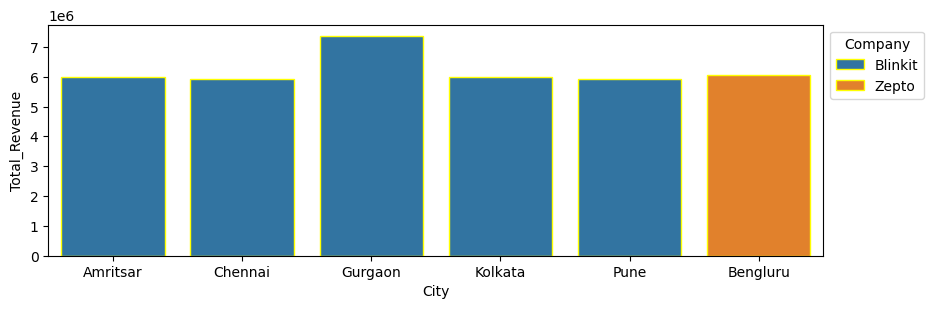

In [60]:
# Set the plot size for a wider view
plt.figure(figsize = (10,3))

# Create a Seaborn barplot comparing City revenue, grouped by Company
sns.barplot(data = best_cities, x = 'City', y = 'Total_Revenue', hue = 'Company', edgecolor = 'yellow')

# Move the legend outside the plot area
plt.legend(title = 'Company', bbox_to_anchor = (1, 1))

# Display the chart
plt.show()

#Q7) Are discounts increasing AOV or they are just decreasing the revenue for the company#

In [59]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [61]:
# Count the number of orders with and without discount
df['Discount_Applied'].value_counts()

Discount_Applied
0    567906
1    379846
Name: count, dtype: int64

In [62]:
# Group Data - Calculate average order value
dis_order_value = df.groupby('Discount_Applied')['Order_Value'].mean()

# Display the result
dis_order_value

Discount_Applied
0    476.417152
1    712.190830
Name: Order_Value, dtype: float64

In [63]:
# Group Data - Calculate sum of items count
dis_items_count = df.groupby('Discount_Applied')['Items_Count'].sum()

# Display the result
dis_items_count

Discount_Applied
0    5854258
1    3920185
Name: Items_Count, dtype: int64

In [64]:
# Check unique values in the column (Result: [1, 0])
x = df['Discount_Applied'].unique()
print(x)

[1 0]


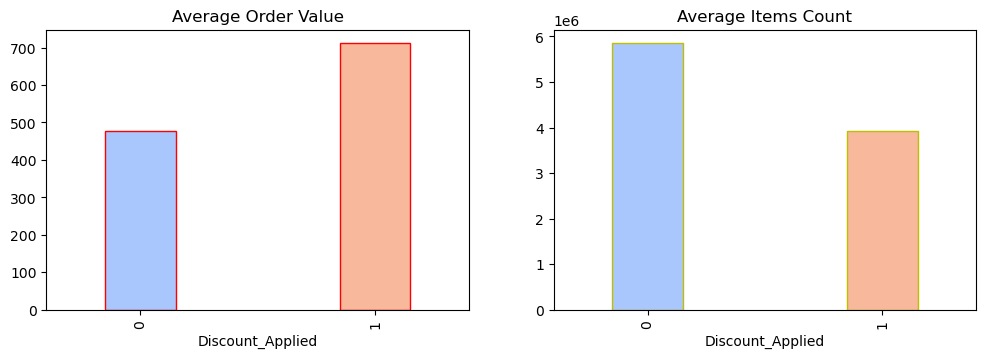

In [65]:
# Create a larger figure to accommodate multiple charts
plt.figure(figsize=(12,8))

# use gradient colors
colors = sns.color_palette("coolwarm", len(x))

# --- First Subplot (Top Left) ---
plt.subplot(2,2,1)
dis_order_value.plot(kind = 'bar', width = 0.3, edgecolor = 'red', color = colors)
plt.title("Average Order Value")

# --- Second Subplot (Top Right) ---
plt.subplot(2,2,2)
dis_items_count.plot(kind = 'bar', width = 0.3, edgecolor = 'y', color = colors)
plt.title("Average Items Count")

# Display the multi-plot figure
plt.show()

#Q8) Which Company has best operational efficiency? (Delivery time vs order volume) #

In [66]:
df.head()

,Order_ID,Company,City,Customer_Age,Order_Value,Delivery_Time_Min,Distance_Km,Items_Count,Product_Category,Payment_Method,Customer_Rating,Discount_Applied,Delivery_Partner_Rating,Delivery_Time_Bucket
0,1000001,Swiggy Instamart,Noida,46,702,19,12.0,12,Dairy,Wallet,2,1,3,Fast Delivery
1,1000002,Flipkart Minutes,Amritsar,56,1007,20,12.7,10,Snacks,Cash on Delivery,2,0,3,Fast Delivery
2,1000003,Flipkart Minutes,Mumbai,18,1212,17,4.8,19,Personal Care,Cash on Delivery,3,0,4,Fast Delivery
3,1000004,Swiggy Instamart,Delhi,23,1179,6,6.4,2,Dairy,Credit Card,5,1,5,Very Fast Delivery
4,1000005,Dunzo,Mumbai,44,586,12,2.4,13,Household,Wallet,4,0,5,Fast Delivery


In [67]:
# Group Data and Apply Aggregate functions
company_efficiency = df.groupby('Company').agg(
    Total_Orders = ('Order_ID', 'count'),
    Avg_Delivery_Time = ('Delivery_Time_Min', 'mean')
).reset_index()

# Display the summary table
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time
0,Amazon Now,118083,18.984155
1,Big Basket,118047,18.027345
2,Blinkit,118887,15.121771
3,Dunzo,118463,14.177060
4,Flipkart Minutes,118965,17.045080
5,Jio Mart,118267,23.013224
6,Swiggy Instamart,118475,16.072690
7,Zepto,118565,9.644313


In [68]:
# Normalize values for fair comparison
from sklearn.preprocessing import MinMaxScaler

# Scaling both columns to the same range (0 to 1) so that they can be fairly compared and combined.
scaler = MinMaxScaler()  # Create a scaling object

company_efficiency[['Total_Orders_Scaled', 'Avg_Delivery_Time_Scaled']] = scaler.fit_transform(
    company_efficiency[['Total_Orders', 'Avg_Delivery_Time']]
)

In [69]:
company_efficiency

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled
0,Amazon Now,118083,18.984155,0.039216,0.698624
1,Big Basket,118047,18.027345,0.000000,0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716
3,Dunzo,118463,14.177060,0.453159,0.339051
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580
5,Jio Mart,118267,23.013224,0.239651,1.000000
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845
7,Zepto,118565,9.644313,0.564270,0.000000


In [70]:
# Calculate Efficiency Score (higher orders, lower time)
company_efficiency['Efficiency_Score'] = company_efficiency['Total_Orders_Scaled'] - company_efficiency['Avg_Delivery_Time_Scaled']

In [71]:
company_efficiency


,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270


In [74]:
# Permanently save the sorted order
eff = company_efficiency.sort_values(by='Efficiency_Score', ascending=False)
eff

,Company,Total_Orders,Avg_Delivery_Time,Total_Orders_Scaled,Avg_Delivery_Time_Scaled,Efficiency_Score
7,Zepto,118565,9.644313,0.564270,0.000000,0.564270
2,Blinkit,118887,15.121771,0.915033,0.409716,0.505317
4,Flipkart Minutes,118965,17.045080,1.000000,0.553580,0.446420
3,Dunzo,118463,14.177060,0.453159,0.339051,0.114108
6,Swiggy Instamart,118475,16.072690,0.466231,0.480845,-0.014614
1,Big Basket,118047,18.027345,0.000000,0.627054,-0.627054
0,Amazon Now,118083,18.984155,0.039216,0.698624,-0.659408
5,Jio Mart,118267,23.013224,0.239651,1.000000,-0.760349


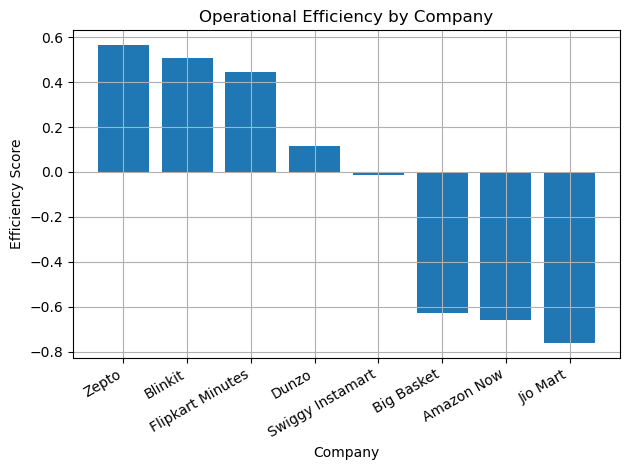

In [76]:
# Plot
# Sort by Efficiency Score (best first) - assumes 'eff' is your summary dataframe
plt.bar( eff['Company'], eff['Efficiency_Score'])

# Adding labels for professionalism
plt.xlabel("Company")
plt.ylabel("Efficiency Score")
plt.title("Operational Efficiency by Company")

# Formatting for better readability
plt.xticks(rotation = 30, ha = 'right')
plt.grid(True)
plt.tight_layout()

# Display the chart
plt.show()

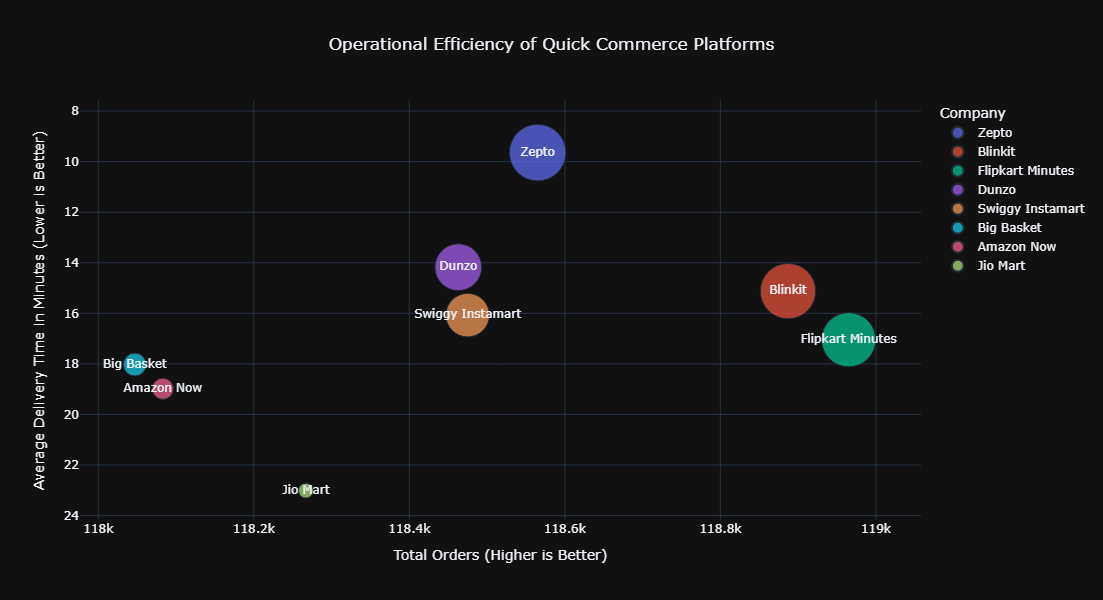

In [81]:
# Use Plotly Library - Scatter Bubble Plot
import plotly.express as px

# Create positive bubble size
# 1. Find the lowest efficiency score (which might be a negative number)
min_eff = eff['Efficiency_Score'].min()

# 2. Shift all scores up so the smallest bubble is positive (0.1) 
# instead of zero or negative, which plotting libraries can't render as a size.
eff['Bubble_Size'] = eff['Efficiency_Score'] - min_eff + 0.1
# Plot using Plotly Express
fig = px.scatter( eff, x = "Total_Orders", y = 'Avg_Delivery_Time', size = 'Bubble_Size', color = 'Company',
                  text = 'Company', title = "Operational Efficiency of Quick Commerce Platforms",width = 1200,  
                    height = 600,  hover_data = { 'Total_Orders': True, 'Avg_Delivery_Time': ':.2f', 'Efficiency_Score': ':.3f' },
                  size_max = 40)

# Make Labels cleaner
fig.update_traces(textposition = 'middle center')

# Improve Chart Layout
fig.update_layout(
    xaxis_title="Total Orders (Higher is Better)",
    yaxis_title="Average Delivery Time in Minutes (Lower is Better)",
    title_x=0.5, # Centers the title
    template="plotly_dark", # Uses a modern dark theme
)
# Reverse Y-axis so best performers appear higher
fig.update_yaxes( autorange = 'reversed' )
fig.show()

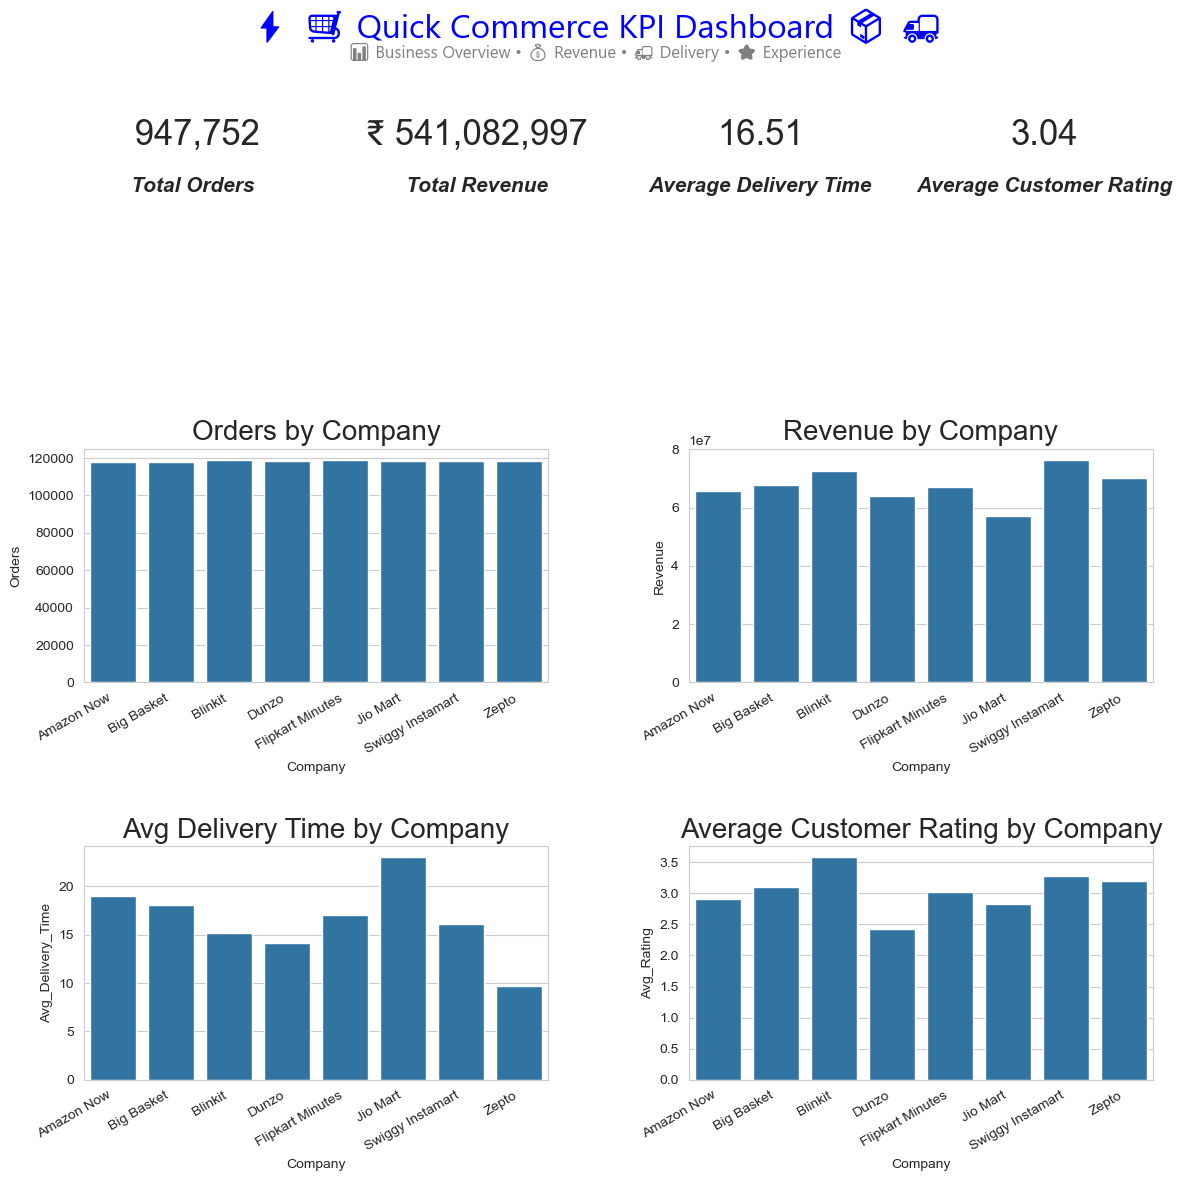

In [87]:
# Create Dashboard Layout
# -------------------------

fig = plt.figure(figsize = (12,12))

sns.set_style("whitegrid")
# -------------------------
# KPI Calculations
# -------------------------

total_orders = df['Order_ID'].count()
total_revenue = df['Order_Value'].sum()
avg_delivery_time = df['Delivery_Time_Min'].mean()
avg_rating = df['Customer_Rating'].mean()

# -------------------------
# KPI CARDS
# -------------------------

# Total Orders Card
plt.subplot2grid((3,4), (0,0))
plt.axis('off')
plt.text(0.5, 0.6, f"{total_orders: ,}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Total Orders", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')

# Total Revenue Card
plt.subplot2grid((3,4), (0,1))
plt.axis('off')
plt.text(0.5, 0.6, f"₹{total_revenue: ,}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Total Revenue", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')

# Average Delivery Time Card
plt.subplot2grid((3,4), (0,2))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_delivery_time:.2f}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Average Delivery Time", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')

# Average Customer Rating Card
plt.subplot2grid((3,4), (0,3))
plt.axis('off')
plt.text(0.5, 0.6, f"{avg_rating:.2f}", fontsize = 25, ha = 'center')
plt.text(0.5, 0.4, "Average Customer Rating", fontsize = 15, ha = 'center', fontstyle = 'italic', fontweight = 'bold')
# -------------------------
# Company Level Metrics
# -------------------------

company_metrics = df.groupby('Company').agg( 
    Orders = ('Order_ID', 'count'),
    Revenue = ("Order_Value", 'sum'),
    Avg_Delivery_Time = ("Delivery_Time_Min", 'mean'),
    Avg_Rating = ("Customer_Rating", 'mean')
).reset_index()

# -------------------------
# Charts Section
# -------------------------

# Orders by company
plt.subplot2grid((3,2), (1,0))
sns.barplot( data = company_metrics, x = 'Company', y = 'Orders')
plt.title("Orders by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')

# Revenue by company
plt.subplot2grid((3,2), (1,1))
sns.barplot( data = company_metrics, x = 'Company', y = 'Revenue')
plt.title("Revenue by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')

# Avg delivery time by company
plt.subplot2grid((3,2), (2,0))
sns.barplot( data = company_metrics, x = 'Company', y = 'Avg_Delivery_Time')
plt.title("Avg Delivery Time by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')

# Avg rating by company
plt.subplot2grid((3,2), (2,1))
sns.barplot( data = company_metrics, x = 'Company', y = 'Avg_Rating')
plt.title("Average Customer Rating by Company", fontsize = 20)
plt.xticks(rotation=30, ha = 'right')
# -------------------------
# Dashboard Title
# -------------------------

plt.rcParams['font.family'] = "Segoe UI Emoji"

plt.suptitle("⚡ 🛒 Quick Commerce KPI Dashboard 📦 🚚", fontsize = 24, color = 'blue')
plt.figtext(0.5, 0.94, "📊 Business Overview • 💰 Revenue • 🚚 Delivery • ⭐ Experience", ha = 'center',
            fontsize = 12, color = 'gray')

plt.tight_layout()
plt.subplots_adjust(hspace = 0.7)
plt.show()